# LLM Agent Framework - Complete Demo
## Interactive Notebook for Team Presentation

This notebook demonstrates 4 core capabilities:
1. **Calling LLM** - Basic LLM inference
2. **Structured Output** - Extracting structured data with Pydantic models
3. **Tool Calling** - LLM invoking tools autonomously
4. **LangGraph Flow** - Building agentic workflows with conditional logic

Each section uses **HuggingFace LLM (Llama 3.1 70B)** as primary and falls back to OpenAI if HF_TOKEN is not set.
Requires either `HF_TOKEN` or `OPENAI_KEY` environment variable.

In [ ]:
# ==========================================
# SETUP & ENVIRONMENT CONFIGURATION
# ==========================================

import os
from dotenv import load_dotenv
import json
import uuid
from typing import Literal, List, Optional, Dict, Annotated
from datetime import datetime
from pydantic import BaseModel, Field

# ===== CUSTOM .ENV PATH =====
# Modify this path to load .env from a custom location
# Examples:
#   - "/path/to/.env" (absolute path)
#   - "../../../.env" (relative path)
#   - ".env" (current directory - default)
ENV_PATH = "../secrets/.env"  # ← CHANGE THIS TO YOUR CUSTOM PATH

# LangChain & LangGraph imports
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, BaseMessage
from langchain_core.tools import tool
from langchain_core.output_parsers import PydanticOutputParser
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Load environment variables from custom path
load_dotenv(dotenv_path=ENV_PATH)
# del os.environ['HF_TOKEN']

print("✅ All imports successful!")
print(f"✅ Environment variables loaded from: {ENV_PATH}")
print("\n🔧 Environment Setup:")
print(f"   - HF_TOKEN available: {bool(os.getenv('HF_TOKEN'))}")
print(f"   - OPENAI_KEY available: {bool(os.getenv('OPENAI_KEY'))}")

✅ All imports successful!
✅ Environment variables loaded from: ../secrets/.env

🔧 Environment Setup:
   - HF_TOKEN available: False
   - OPENAI_KEY available: True


---
## Use Case 1: Calling LLM
### Basic LLM Inference with Multiple Models

Demonstrate how to initialize and call an LLM with simple prompts.

In [18]:
# ==========================================
# USE CASE 1: CALLING LLM
# ==========================================

def setup_hf_llm():
    """Initialize HuggingFace LLM client (Llama 3.1 70B)."""
    hf_token = os.getenv('HF_TOKEN')
    if not hf_token:
        raise ValueError("❌ HF_TOKEN not set. Please set your HuggingFace API token.")
    
    hf_llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-70B-Instruct",
        huggingfacehub_api_token=hf_token,
        task="conversational",
        temperature=0.7,
        max_new_tokens=500
    )
    llm = ChatHuggingFace(llm=hf_llm)
    return llm

def setup_openai_llm():
    """Initialize OpenAI LLM client (fallback)."""
    api_key = os.getenv('OPENAI_KEY')
    if not api_key:
        raise ValueError("❌ OPENAI_KEY not set. Please set your OpenAI API key.")
    
    llm = ChatOpenAI(
        model="gpt-4.1-mini",
        api_key=api_key,
        temperature=0.7,
        max_tokens=500
    )
    return llm

# Initialize LLM - Try HuggingFace first, fallback to OpenAI
try:
    llm = setup_hf_llm()
    print("✅ HuggingFace LLM (Llama 3.1 70B) initialized successfully")
except ValueError as e:
    print(f"⚠️  {e}")
    try:
        llm = setup_openai_llm()
        print("✅ Fallback: OpenAI LLM initialized successfully")
    except ValueError as e2:
        print(f"❌ {e2}")

⚠️  ❌ HF_TOKEN not set. Please set your HuggingFace API token.
✅ Fallback: OpenAI LLM initialized successfully


In [19]:
# ==========================================
# DEMO 1.1: Simple LLM Call
# ==========================================

print("\n" + "="*60)
print("DEMO 1.1: Simple LLM Call")
print("="*60)

messages = [
    SystemMessage(content="You are a helpful IT support assistant."),
    HumanMessage(content="What are the best practices for password security?")
]

response = llm.invoke(messages)

print("\n📝 User Query:")
print("   'What are the best practices for password security?'")
print("\n🤖 LLM Response:")
print(f"\n{response.content}")
print("\n✅ Demo completed!")


DEMO 1.1: Simple LLM Call

📝 User Query:
   'What are the best practices for password security?'

🤖 LLM Response:

Best practices for password security include the following:

1. **Use Strong, Unique Passwords:** Create passwords that are long (at least 12 characters), include a mix of uppercase and lowercase letters, numbers, and special characters. Avoid common words, phrases, or easily guessable information such as birthdays or names.

2. **Avoid Reusing Passwords:** Use a unique password for each account or service to prevent a breach on one platform from compromising others.

3. **Use a Password Manager:** Password managers can generate, store, and autofill complex passwords securely, reducing the need to remember multiple passwords.

4. **Enable Multi-Factor Authentication (MFA):** Whenever possible, enable MFA to add an extra layer of security beyond just the password.

5. **Change Passwords Regularly:** Update passwords periodically, especially if you suspect any compromise or

In [20]:
# ==========================================
# DEMO 1.2: Multi-turn Conversation
# ==========================================

print("\n" + "="*60)
print("DEMO 1.2: Multi-turn Conversation")
print("="*60)

conversation_history = [
    SystemMessage(content="You are an IT support assistant helping with common issues."),
    HumanMessage(content="How do I connect to the VPN?"),
]

# First turn
response1 = llm.invoke(conversation_history)
conversation_history.append(AIMessage(content=response1.content))

print("\n📝 Turn 1 - User:")
print("   'How do I connect to the VPN?'")
print("\n🤖 Assistant Response:")
print(f"{response1.content}")

# Second turn - follow-up question
conversation_history.append(HumanMessage(content="What if I forgot my VPN password?"))
response2 = llm.invoke(conversation_history)

print("\n\n📝 Turn 2 - User Follow-up:")
print("   'What if I forgot my VPN password?'")
print("\n🤖 Assistant Response:")
print(f"{response2.content}")
print("\n✅ Multi-turn demo completed!")


DEMO 1.2: Multi-turn Conversation

📝 Turn 1 - User:
   'How do I connect to the VPN?'

🤖 Assistant Response:
To help you connect to the VPN, could you please provide a bit more information?

1. What VPN service or software are you using? (e.g., Cisco AnyConnect, OpenVPN, Windows built-in VPN)
2. What device and operating system are you on? (e.g., Windows 10, macOS, iPhone)
3. Do you have the VPN credentials and server address?

In general, the steps to connect to a VPN are:

1. Open your VPN client or go to your device’s network settings.
2. Enter the VPN server address.
3. Enter your username and password.
4. Click Connect.

Let me know the details, and I can give you more specific instructions!


📝 Turn 2 - User Follow-up:
   'What if I forgot my VPN password?'

🤖 Assistant Response:
If you forgot your VPN password, here are the steps you can take:

1. **Reset your password:**  
   - Check if your VPN service has a password reset option on its login page or portal.  
   - Follow the

---
## Use Case 2: Structured Output
### Extract Information into Pydantic Models

Demonstrate structured output extraction using LLMs with Pydantic models.

In [21]:
# ==========================================
# USE CASE 2: STRUCTURED OUTPUT
# ==========================================

# Define Pydantic models for structured output
class EmployeeInfo(BaseModel):
    """Extract employee information from text."""
    name: str = Field(description="Full name of the employee")
    email: str = Field(description="Email address")
    department: str = Field(description="Department they work in")
    skills: List[str] = Field(description="Technical skills")
    years_experience: Optional[int] = Field(default=None, description="Years in current role")

class SupportRequest(BaseModel):
    """Categorize IT support requests."""
    issue_category: Literal["hardware", "software", "network", "access", "other"] = Field(
        description="Category of the IT issue"
    )
    priority: Literal["low", "medium", "high", "critical"] = Field(
        description="Priority level"
    )
    description: str = Field(description="Brief description of the issue")
    requires_ticket: bool = Field(description="Whether a ticket should be created")

print("✅ Pydantic models defined for structured output")

✅ Pydantic models defined for structured output


In [22]:
# ==========================================
# DEMO 2.1: Extract Employee Information
# ==========================================

print("\n" + "="*60)
print("DEMO 2.1: Extract Employee Information")
print("="*60)

# Setup HF LLM with structured output using parser
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    hf_llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-70B-Instruct",
        huggingfacehub_api_token=hf_token,
        task="conversational",
        temperature=0.0,
        max_new_tokens=300
    )
    llm_structured = ChatHuggingFace(llm=hf_llm)
else:
    llm_structured = ChatOpenAI(
        model="gpt-4.1-mini",
        api_key=os.getenv('OPENAI_KEY'),
        temperature=0.0,
    )

parser = PydanticOutputParser(pydantic_object=EmployeeInfo)

# Sample text to extract from
employee_text = """
Hi, I'm Sarah Chen. You can reach me at sarah.chen@company.com.
I work in the Cloud Engineering department.
I have expertise in Python, Kubernetes, and AWS.
I've been working in this role for 4 years.
"""

system_prompt = f"""Extract employee information from the given text. 
Return ONLY valid JSON matching the schema.

{parser.get_format_instructions()}
"""

messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(content=employee_text)
]

response = llm_structured.invoke(messages)
extracted_info = parser.invoke(response)

print("\n📝 Input Text:")
print(employee_text.strip())

print("\n📊 Extracted Structured Data:")
print(json.dumps(extracted_info.model_dump(), indent=2))
print("\n✅ Structured extraction completed!")


DEMO 2.1: Extract Employee Information

📝 Input Text:
Hi, I'm Sarah Chen. You can reach me at sarah.chen@company.com.
I work in the Cloud Engineering department.
I have expertise in Python, Kubernetes, and AWS.
I've been working in this role for 4 years.

📊 Extracted Structured Data:
{
  "name": "Sarah Chen",
  "email": "sarah.chen@company.com",
  "department": "Cloud Engineering",
  "skills": [
    "Python",
    "Kubernetes",
    "AWS"
  ],
  "years_experience": 4
}

✅ Structured extraction completed!


In [23]:
# ==========================================
# DEMO 2.2: Classify Support Requests
# ==========================================

print("\n" + "="*60)
print("DEMO 2.2: Classify IT Support Requests")
print("="*60)

# Setup HF LLM classifier with parser
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    hf_llm_classifier = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-70B-Instruct",
        huggingfacehub_api_token=hf_token,
        task="conversational",
        temperature=0.0,
        max_new_tokens=200
    )
    llm_classifier = ChatHuggingFace(llm=hf_llm_classifier)
else:
    llm_classifier = ChatOpenAI(
        model="gpt-4.1-mini",
        api_key=os.getenv('OPENAI_KEY'),
        temperature=0.0,
    )

parser_classifier = PydanticOutputParser(pydantic_object=SupportRequest)

# Example support requests to classify
support_requests = [
    "My laptop won't turn on anymore. It's been making a beeping sound for days.",
    "I can't access the project repository. I need code review permissions.",
    "The office WiFi keeps disconnecting every hour.",
    "Can you help me install the latest version of Python?"
]

print("\n📋 Classifying Support Requests:\n")

for i, request in enumerate(support_requests, 1):
    system_prompt = f"""Classify this IT support request. Return only valid JSON.

{parser_classifier.get_format_instructions()}
"""
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=request)
    ]
    
    response = llm_classifier.invoke(messages)
    classification = parser_classifier.invoke(response)
    
    print(f"Request {i}: {request}")
    print(f"  ├─ Category: {classification.issue_category.upper()}")
    print(f"  ├─ Priority: {classification.priority.upper()}")
    print(f"  ├─ Description: {classification.description}")
    print(f"  └─ Requires Ticket: {classification.requires_ticket}\n")

print("✅ Classification completed!")


DEMO 2.2: Classify IT Support Requests

📋 Classifying Support Requests:

Request 1: My laptop won't turn on anymore. It's been making a beeping sound for days.
  ├─ Category: HARDWARE
  ├─ Priority: HIGH
  ├─ Description: Laptop won't turn on and has been making a beeping sound for days.
  └─ Requires Ticket: True

Request 2: I can't access the project repository. I need code review permissions.
  ├─ Category: ACCESS
  ├─ Priority: MEDIUM
  ├─ Description: User cannot access the project repository and requires code review permissions.
  └─ Requires Ticket: True

Request 3: The office WiFi keeps disconnecting every hour.
  ├─ Category: NETWORK
  ├─ Priority: MEDIUM
  ├─ Description: The office WiFi keeps disconnecting every hour.
  └─ Requires Ticket: True

Request 4: Can you help me install the latest version of Python?
  ├─ Category: SOFTWARE
  ├─ Priority: LOW
  ├─ Description: Request for assistance with installing the latest version of Python.
  └─ Requires Ticket: False

✅ Classi

---
## Use Case 3: Tool Calling
### LLM Autonomously Calling Tools

Demonstrate how LLMs can decide to call tools and process their results.

In [24]:
# ==========================================
# USE CASE 3: TOOL CALLING
# ==========================================

# Define tools
@tool
def get_employee_info(employee_id: str) -> dict:
    """Retrieve employee information from the company database.
    
    Args:
        employee_id: The unique employee ID (e.g., 'EMP001')
    
    Returns:
        Employee details including name, department, and contact info
    """
    # Simulated employee database
    employees = {
        "EMP001": {"name": "Alice Johnson", "department": "Engineering", "email": "alice@company.com"},
        "EMP002": {"name": "Bob Smith", "department": "HR", "email": "bob@company.com"},
        "EMP003": {"name": "Carol White", "department": "IT", "email": "carol@company.com"},
    }
    employee = employees.get(employee_id)
    if not employee:
        return {"error": f"Employee {employee_id} not found"}
    return employee

@tool
def create_support_ticket(title: str, description: str, priority: str) -> dict:
    """Create a new IT support ticket.
    
    Args:
        title: Brief title of the issue
        description: Detailed description of the problem
        priority: Priority level (low, medium, high, critical)
    
    Returns:
        Ticket confirmation with ticket ID
    """
    ticket_id = f"TICKET-{str(uuid.uuid4())[:8].upper()}"
    return {
        "status": "created",
        "ticket_id": ticket_id,
        "title": title,
        "priority": priority,
        "timestamp": datetime.now().isoformat()
    }

@tool
def check_system_status(system_name: str) -> dict:
    """Check the status of a company system.
    
    Args:
        system_name: Name of the system (email, vpn, fileserver, etc.)
    
    Returns:
        System status information
    """
    # Simulated system status
    systems = {
        "email": {"status": "operational", "uptime": "99.8%"},
        "vpn": {"status": "operational", "uptime": "99.9%"},
        "fileserver": {"status": "degraded", "uptime": "95.2%", "message": "High disk usage"},
        "slack": {"status": "operational", "uptime": "99.95%"},
    }
    system = systems.get(system_name.lower())
    if not system:
        return {"status": "unknown", "message": f"System {system_name} not found"}
    return system

# Define available tools
tools = [get_employee_info, create_support_ticket, check_system_status]

print("✅ Tools defined:")
for tool_def in tools:
    print(f"   - {tool_def.name}: {tool_def.description.split(chr(10))[0]}")

✅ Tools defined:
   - get_employee_info: Retrieve employee information from the company database.
   - create_support_ticket: Create a new IT support ticket.
   - check_system_status: Check the status of a company system.


In [25]:
# ==========================================
# DEMO 3.1: LLM Calling Tools
# ==========================================

print("\n" + "="*60)
print("DEMO 3.1: LLM Autonomously Calling Tools")
print("="*60)

# Setup LLM with tools - Try HF first, fallback to OpenAI
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    hf_llm_tools = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-70B-Instruct",
        huggingfacehub_api_token=hf_token,
        task="conversational",
        temperature=0.0,
        max_new_tokens=500
    )
    llm_with_tools = ChatHuggingFace(llm=hf_llm_tools).bind_tools(tools)
else:
    llm_with_tools = ChatOpenAI(
        model="gpt-4.1-mini",
        api_key=os.getenv('OPENAI_KEY'),
        temperature=0.0,
    ).bind_tools(tools)

user_query = "What's the email of employee EMP001 and the status of the VPN system?"

messages = [
    SystemMessage(content="You are an IT assistant. Use tools to answer user queries accurately."),
    HumanMessage(content=user_query)
]

print(f"\n📝 User Query:\n   '{user_query}'")

# Get LLM response
response = llm_with_tools.invoke(messages)

print("\n🔧 Tools Called by LLM:")
if response.tool_calls:
    for tool_call in response.tool_calls:
        print(f"   ✓ {tool_call['name']}({tool_call['args']})")
else:
    print("   No tools called")

# Process tool calls
print("\n📊 Tool Execution Results:")
tool_results = []
for tool_call in response.tool_calls:
    tool_name = tool_call['name']
    tool_args = tool_call['args']
    
    # Map tool name to function
    tool_map = {t.name: t for t in tools}
    tool_func = tool_map[tool_name]
    result = tool_func.invoke(tool_args)
    
    print(f"\n   {tool_name}({json.dumps(tool_args)}):") 
    print(f"   └─ Result: {json.dumps(result, indent=6)}")
    
    tool_results.append((tool_name, result))

print("\n✅ Tool calling demo completed!")


DEMO 3.1: LLM Autonomously Calling Tools

📝 User Query:
   'What's the email of employee EMP001 and the status of the VPN system?'

🔧 Tools Called by LLM:
   ✓ get_employee_info({'employee_id': 'EMP001'})
   ✓ check_system_status({'system_name': 'vpn'})

📊 Tool Execution Results:

   get_employee_info({"employee_id": "EMP001"}):
   └─ Result: {
      "name": "Alice Johnson",
      "department": "Engineering",
      "email": "alice@company.com"
}

   check_system_status({"system_name": "vpn"}):
   └─ Result: {
      "status": "operational",
      "uptime": "99.9%"
}

✅ Tool calling demo completed!


In [26]:
# ==========================================
# DEMO 3.2: Interactive Tool Calling
# ==========================================

print("\n" + "="*60)
print("DEMO 3.2: Create Support Ticket via LLM")
print("="*60)

user_query = "The file server seems to be running slow. Can you check its status and create a ticket if needed?"

messages = [
    SystemMessage(content="You are an IT assistant. Use tools to help users. If a system has issues, create a ticket."),
    HumanMessage(content=user_query)
]

print(f"\n📝 User Query:\n   '{user_query}'")

response = llm_with_tools.invoke(messages)

print("\n🔧 Tools Called:")
for tool_call in response.tool_calls:
    print(f"   ✓ {tool_call['name']}({tool_call['args']})")

# Execute tools
print("\n📊 Results:")
for tool_call in response.tool_calls:
    tool_name = tool_call['name']
    tool_args = tool_call['args']
    tool_map = {t.name: t for t in tools}
    result = tool_map[tool_name].invoke(tool_args)
    
    print(f"\n   {tool_name}:")
    for key, value in result.items():
        print(f"      {key}: {value}")

print("\n✅ Support ticket workflow completed!")


DEMO 3.2: Create Support Ticket via LLM

📝 User Query:
   'The file server seems to be running slow. Can you check its status and create a ticket if needed?'

🔧 Tools Called:
   ✓ check_system_status({'system_name': 'fileserver'})

📊 Results:

   check_system_status:
      status: degraded
      uptime: 95.2%
      message: High disk usage

✅ Support ticket workflow completed!


---
## Use Case 4: LangGraph Workflow
### Building Agentic Workflows with Conditional Logic

Demonstrate a complete workflow with normal edges and conditional routing.

In [62]:
# ==========================================
# USE CASE 4: LANGGRAPH WORKFLOW
# ==========================================

# Define the graph state
from typing import TypedDict, Annotated, List, Optional, Dict
class GraphState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    query: str
    issue_type: str
    reasoning: str

# Define routing classification model
class IssueClassification(BaseModel):
    issue_type: Literal["faq", "urgent", "access"] = Field(description="Type of issue")
    requires_ticket: bool = Field(description="Whether to create a ticket")
    reasoning: str = Field(description="Why this classification was chosen")

print("✅ Workflow state and models defined")

✅ Workflow state and models defined


In [63]:
# ==========================================
# DEFINE WORKFLOW NODES
# ==========================================

def input_node(state: GraphState):
    """Node 1: Process and log the user query."""
    print(f"\n[INPUT NODE] Processing query: {state.get('query', '')}")
    state['processed'] = True
    state['timestamp'] = datetime.now().isoformat()
    return state

def classify_node(state: GraphState):
    """Node 2: Classify the issue type using LLM."""
    query = state.get('query', '')
    
    print(f"\n[CLASSIFY NODE] Analyzing issue type...")
    
    # Use HF as primary, fallback to OpenAI
    hf_token = os.getenv('HF_TOKEN')
    parser_wf = PydanticOutputParser(pydantic_object=IssueClassification)
    
    if hf_token:
        hf_llm_classify = HuggingFaceEndpoint(
            repo_id="meta-llama/Llama-3.1-70B-Instruct",
            huggingfacehub_api_token=hf_token,
            task="conversational",
            temperature=0.0,
            max_new_tokens=200
        )
        llm_classifier = ChatHuggingFace(llm=hf_llm_classify)
    else:
        llm_classifier = ChatOpenAI(
            model="gpt-4.1-mini",
            api_key=os.getenv('OPENAI_KEY'),
            temperature=0.0,
        )
    
    system_prompt = f"""Classify this IT support issue. Return only valid JSON.

{parser_wf.get_format_instructions()}
"""
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=query)
    ]
    
    response = llm_classifier.invoke(messages)
    classification = parser_wf.invoke(response)
    

    return {"issue_type":classification.issue_type, "reasoning": classification.reasoning}

def faq_node(state: GraphState):
    print("Working in FAQ Node")

def urgent_node(state: GraphState):
    print("Working in Urgent Node")

def access_node(state: GraphState):
    print("Working in Access Node")

def output_node(state: GraphState):
    print("Working in Output Node")

In [64]:
# ==========================================
# DEFINE CONDITIONAL ROUTING
# ==========================================

def route_based_on_issue_type(state: dict) -> str:
    """Conditional router: Direct to appropriate handler based on issue type."""
    issue_type = state.get('issue_type', 'faq')
    
    routing_map = {
        'faq': 'faq_handler',
        'urgent': 'urgent_handler',
        'access': 'access_handler'
    }
    
    route = routing_map.get(issue_type, 'faq_handler')
    print(f"\n[ROUTER] Routing to: {route}")
    return route

print("✅ Routing logic defined")

✅ Routing logic defined


In [65]:
# ==========================================
# BUILD THE GRAPH
# ==========================================
graph = StateGraph(GraphState)

# Add nodes
graph.add_node("input", input_node)
graph.add_node("classify", classify_node)
graph.add_node("faq_handler", faq_node)
graph.add_node("urgent_handler", urgent_node)
graph.add_node("access_handler", access_node)
graph.add_node("output", output_node)

# Add edges (linear path)
graph.add_edge(START, "input")
graph.add_edge("input", "classify")

# Add conditional edges (branching logic)
graph.add_conditional_edges(
    "classify",
    route_based_on_issue_type,
    {
        "faq_handler": "faq_handler",
        "urgent_handler": "urgent_handler",
        "access_handler": "access_handler"
    }
)

# All handlers converge to output
graph.add_edge("faq_handler", "output")
graph.add_edge("urgent_handler", "output")
graph.add_edge("access_handler", "output")

# Output goes to end
graph.add_edge("output", END)

# Compile the graph
app = graph.compile()

# print("✅ LangGraph workflow built and compiled")
# print("\n📊 Workflow Structure:")
# print("   START → input → classify ⟳")
# print("                    ├→ faq_handler →┐")
# print("                    ├→ urgent_handler ┼→ output → END")
# print("                    └→ access_handler →┘")

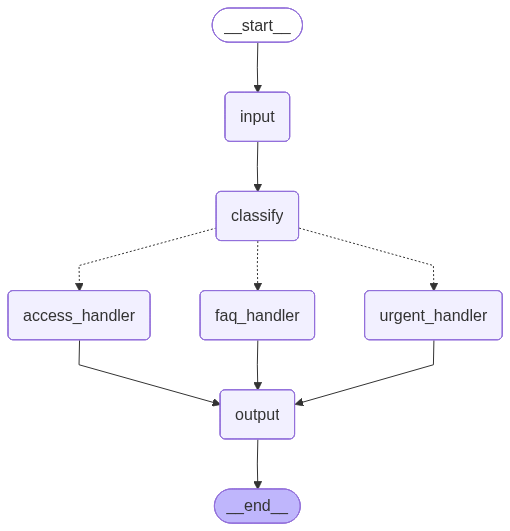

In [66]:
from IPython.display import Image, display
img = app.get_graph(xray=False).draw_mermaid_png(background_color="white")
display(
    Image(img)
)

In [ ]:
# app.invoke({"query": "My laptop is not working, can you look into this priority"})
app.invoke({"query": "i want to request for VPM acces"})


[INPUT NODE] Processing query: i want to request for VPM acces

[CLASSIFY NODE] Analyzing issue type...

[ROUTER] Routing to: access_handler
Working in Access Node
Working in Output Node


{'messages': [],
 'query': 'i want to request for VPM acces',
 'issue_type': 'access',
 'reasoning': 'The user is requesting access to a VPN, which is an access-related issue and typically requires a ticket to process the access request.'}

---
## Summary & Key Takeaways

### Use Case 1: Calling LLM ✅
- Initialize LLM clients (OpenAI, HuggingFace)
- Send messages and receive responses
- Support multi-turn conversations

### Use Case 2: Structured Output ✅
- Define Pydantic models for expected output format
- Use `.with_structured_output()` for consistent JSON responses
- Extract and classify information reliably

### Use Case 3: Tool Calling ✅
- Define tools with `@tool` decorator and docstrings
- LLM autonomously decides which tools to call
- Process tool results and integrate into workflow

### Use Case 4: LangGraph Workflow ✅
- Build stateful workflows with nodes and edges
- Implement conditional routing based on LLM decisions
- Create scalable, maintainable agent architectures

---